<a href="https://colab.research.google.com/github/Kafkasyahrial/data-science-2026/blob/main/Pertemuan11_KafkaSyahrial_%5B240401010045%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pertemuan 11 - Aktivitas Hands-on**

Nama: Kafka Syahrial Fauzan

NIM: 240401010045

Prodi: Informatika - Universitas Siber Asia

Langkah 1 - Generate & Eksplorasi Dataset

Shape dataset: (300, 4)

Statistik Deskriptif:
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


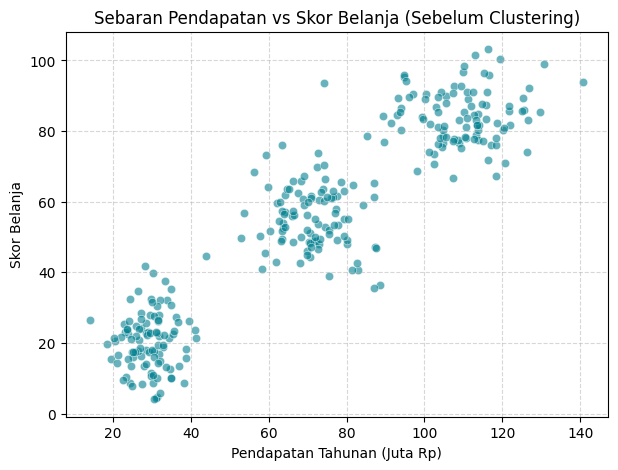

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2))    # Kelompok Hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))   # Kelompok Menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))  # Kelompok Boros

data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])

# Menambahkan kolom acak tambahan sesuai panduan modul
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

# Menampilkan informasi awal dataset
print('Shape dataset:', df.shape)
print("\nStatistik Deskriptif:")
print(df.describe().round(2))

# Visualisasi sebaran data awal
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6, color='#028090')
plt.title('Sebaran Pendapatan vs Skor Belanja (Sebelum Clustering)')
plt.xlabel('Pendapatan Tahunan (Juta Rp)')
plt.ylabel('Skor Belanja')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Langkah 2 - Preprocessing Data

In [2]:
from sklearn.preprocessing import StandardScaler

# Memilih fitur numerik yang akan digunakan untuk clustering
X = df[['pendapatan_tahunan', 'skor_belanja']].values

# Menerapkan Standarisasi Fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling (mendekati 0):', X_scaled.mean(axis=0).round(3))
print('Standar Deviasi setelah scaling (mendekati 1):', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling (mendekati 0): [-0.  0.]
Standar Deviasi setelah scaling (mendekati 1): [1. 1.]


Di langkah ini, fitur numerik yang relevan (pendapatan_tahunan dan skor_belanja) akan diekstrak dan disamakan skalanya menggunakan StandardScaler.

Langkah 3 - Metode Elbow untuk Menentukan K

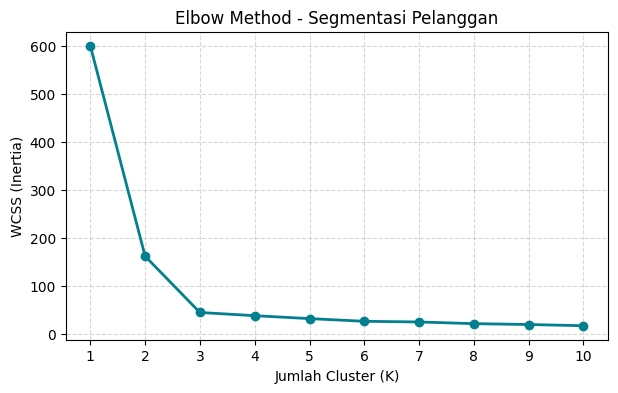

In [3]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Plot grafik Metode Elbow
plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), wcss, marker='o', color='#028090', lw=2)
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method - Segmentasi Pelanggan')
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Mengevaluasi performa nilai $K$ dari 1 sampai 10 menggunakan metrik WCSS (Within-Cluster Sum of Squares) untuk mencari jumlah cluster optimal.

### **Interpretasi Metode Elbow:**
1. **Analisis Siku (Elbow Point):** Berdasarkan grafik di atas, penurunan nilai WCSS terlihat mulai melandai secara tajam (membentuk siku) pada titik **K = 3**.
2. **Kesesuaian Data:** Hasil pengamatan grafik Elbow ini sangat sesuai dengan skenario jumlah kelompok tersembunyi yang diharapkan saat pembuatan dataset awal (kelompok hemat, menengah, dan boros). Oleh karena itu, jumlah cluster optimal yang dipilih adalah **K = 3**.

Langkah 4 - Melatih Model K-Means

In [5]:
from sklearn.metrics import silhouette_score

# Melatih model dengan K optimal
model = KMeans(n_clusters=3, random_state=42, init='k-means++')
model.fit(X_scaled)

# Menyimpan label ke dalam dataframe utama
df['cluster'] = model.labels_

print(f'WCSS Akhir (Inertia): {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')

print("\nNilai Rata-rata Fitur Asli per Cluster:")
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))

WCSS Akhir (Inertia): 44.556
Silhouette Score: 0.695

Nilai Rata-rata Fitur Asli per Cluster:
         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08


Melatih model akhir menggunakan $K=3$ serta menghitung Inertia/WCSS akhir dan nilai Silhouette Score.

Langkah 5 - Visualisasi Hasil Clustering

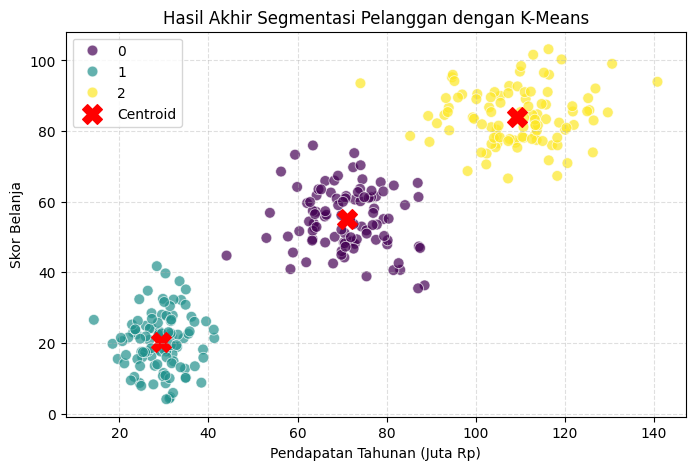

In [6]:
# Mengembalikan posisi titik pusat (centroid) ke skala asal
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(8, 5))
# Scatter plot untuk data tiap cluster
sns.scatterplot(
    data=df, x='pendapatan_tahunan', y='skor_belanja',
    hue='cluster', palette='viridis', alpha=0.7, s=60
)
# Menampilkan centroid
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    c='red', marker='X', s=200, label='Centroid'
)

plt.xlabel('Pendapatan Tahunan (Juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Hasil Akhir Segmentasi Pelanggan dengan K-Means')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

### **Profil Karakteristik Segmen Pelanggan:**
Berdasarkan hasil visualisasi dan nilai rata-rata tiap cluster, segmen pelanggan dapat diidentifikasi sebagai berikut:
* **Cluster 0:** Kelompok pelanggan dengan **pendapatan tahunan rendah** dan **skor belanja rendah**. Kelompok ini merepresentasikan segmen **'Hemat'**.
* **Cluster 1:** Kelompok pelanggan dengan **pendapatan tahunan menengah** dan **skor belanja menengah**. Kelompok ini merepresentasikan segmen **'Menengah'**.
* **Cluster 2:** Kelompok pelanggan dengan **pendapatan tahunan tinggi** dan **skor belanja tinggi**. Kelompok ini merepresentasikan segmen **'Boros / Premium'**.

Langkah 6 - Hierarchical Clustering (Pembanding)

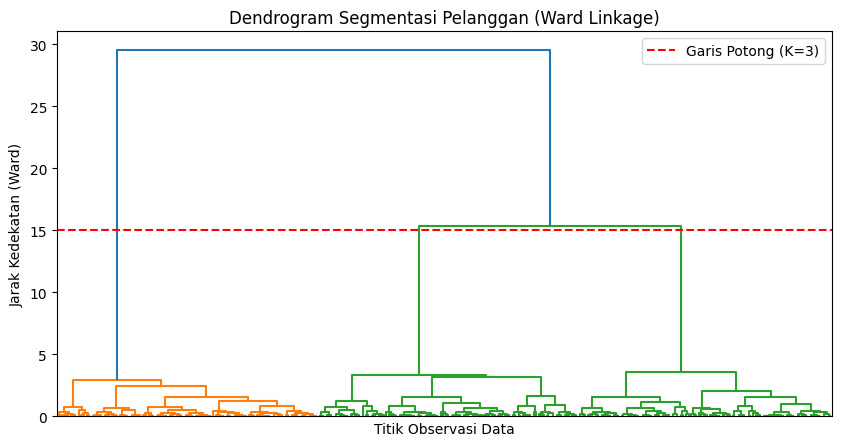

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Menghitung matriks linkage menggunakan metode Ward
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z, no_labels=True)  # Menyembunyikan indeks agar grafik tidak terlalu padat
plt.title('Dendrogram Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Titik Observasi Data')
plt.ylabel('Jarak Kedekatan (Ward)')

# Garis potong horizontal hipotesis untuk menghasilkan 3 cluster
plt.axhline(y=15, color='red', linestyle='--', label='Garis Potong (K=3)')
plt.legend()
plt.show()

### **Kesimpulan Analisis Perbandingan:**
Ketika dendrogram dipotong secara horizontal pada jarak ambang batas tertentu (misalnya $y=15$), struktur pohon terbagi menjadi **3 garis vertikal utama**. Hal ini membuktikan bahwa hasil pengelompokan menggunakan **Hierarchical Clustering (Ward Linkage)** memberikan hasil yang konsisten dan memperkuat pilihan **K = 3** yang didapatkan dari **Metode Elbow K-Means** sebelumnya.